In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from tqdm import tqdm

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


Training: 100%|██████████| 94/94 [00:28<00:00,  3.28batch/s]


Train MSE: 0.05646930353965762


Validating: 100%|██████████| 4000/4000 [00:01<00:00, 3977.19image/s]


Validation MSE: 0.03997645569794076
Best weights updated and saved.


Epoch 2/5


...

Validation MSE: 0.02165996667386251
Best weights updated and saved.


Epoch 5/5


Training: 100%|██████████| 94/94 [00:28<00:00,  3.27batch/s]


Train MSE: 0.020199738970352453


Validating: 100%|██████████| 4000/4000 [00:01<00:00, 3442.20image/s]


Validation MSE: 0.0227194524199163




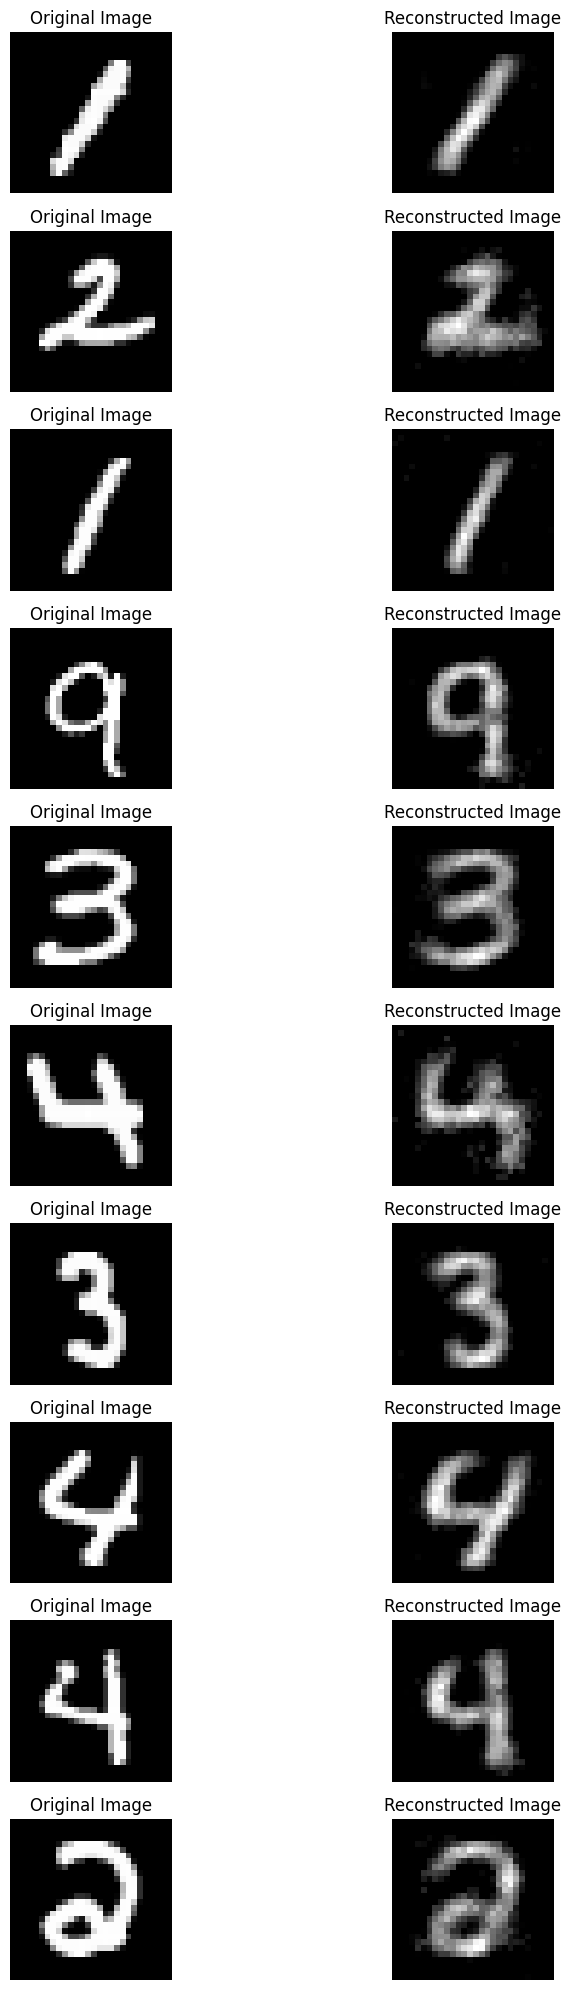

In [2]:
class AE:
    def __init__(self):
        self.epoch_number = 5
        self.learning_rate = 0.01
        self.momentum = 0.9
        self.hidden_layer_neurons = [256, 128, 128, 256]
        self.layer_neurons = [784, 784]
        self.layer_neurons[1:1] = self.hidden_layer_neurons
        self.activation_type = "relu"
        self.batch_size = 128
        self.all_weights, self.all_velocities = self.initialize_weights_and_velocities()
        self.train_mse_list = []
        self.validation_mse_list = []
        self.best_val_mse = float('inf')

        self.train_images, self.train_labels, self.val_images, self.val_labels, self.test_images, self.test_labels = self.read_data()
        self.train()

    def initialize_weights_and_velocities(self):
        weights = []
        velocities = []
        for i in range(len(self.layer_neurons) - 1):
            n_in = self.layer_neurons[i]
            n_out = self.layer_neurons[i + 1]

            if self.activation_type in ["relu", "lrelu"]:
                stddev = np.sqrt(1.0 / n_in)
                layer_weights = np.random.normal(0, stddev, (n_out, n_in + 1))
            elif self.activation_type == "sigmoid":
                bound = np.sqrt(6.0 / (n_in + n_out))
                layer_weights = np.random.uniform(-bound, bound, (n_out, n_in + 1))
            else:
                raise ValueError(f"Unsupported activation function: {self.activation_type}")

            layer_velocities = np.zeros_like(layer_weights)
            weights.append(layer_weights)
            velocities.append(layer_velocities)
        return weights, velocities

    def read_data(self):
        (train_images, _), (test_images, _) = mnist.load_data()
        train_images = train_images[:20000].reshape(-1, 784) / 255.0
        train_images, remaining_images = train_test_split(train_images, train_size=0.6, shuffle=False)
        val_images, test_images = train_test_split(remaining_images, test_size=0.5, shuffle=False)
        return train_images, None, val_images, None, test_images, None

    def activation(self, x):
        if self.activation_type == "relu":
            return np.maximum(0, x)
        elif self.activation_type == "lrelu":
            alpha = 0.01
            return np.maximum(alpha * x, x)
        elif self.activation_type == "sigmoid":
            return 1 / (1 + np.exp(-x))

    def activation_derivative(self, x):
        if self.activation_type == "relu":
            return np.where(x > 0, 1, 0)
        elif self.activation_type == "lrelu":
            alpha = 0.01
            return np.where(x > 0, 1, alpha)
        elif self.activation_type == "sigmoid":
            sigmoid_x = self.activation(x)
            return sigmoid_x * (1 - sigmoid_x)

    def forward_pass(self, data):
        data = np.append(data, [1])
        activations = [data]
        y_ins = []

        for weights in self.all_weights:
            y_in = np.dot(weights, data)
            y_ins.append(y_in)
            data = self.activation(y_in)
            data = np.append(data, [1])
            activations.append(data)

        return activations, y_ins

    def backward_pass(self, activations, y_ins, target):
        deltas = [target - activations[-1][:-1]]
        for i in range(len(self.all_weights) - 1, 0, -1):
            delta = np.dot(self.all_weights[i].T[:-1], deltas[-1]) * self.activation_derivative(y_ins[i - 1])
            deltas.append(delta)

        deltas.reverse()
        return deltas

    def update_weights(self, batch_deltas, batch_activations):
        for i in range(len(self.all_weights)):
            sum_delta_weights = np.zeros_like(self.all_weights[i][:, :-1])
            sum_delta_bias = np.zeros_like(self.all_weights[i][:, -1])
            for j in range(len(batch_activations)):
                delta_weights = self.learning_rate * np.outer(batch_deltas[j][i], batch_activations[j][i][:-1])
                delta_bias = self.learning_rate * batch_deltas[j][i]
                sum_delta_weights += delta_weights
                sum_delta_bias += delta_bias

            if self.momentum == 0.0:
                self.all_weights[i][:, :-1] += sum_delta_weights / len(batch_activations)
                self.all_weights[i][:, -1] += sum_delta_bias / len(batch_activations)
            else:
                self.all_velocities[i][:, :-1] = self.momentum * self.all_velocities[i][:, :-1] + sum_delta_weights / len(batch_activations)
                self.all_velocities[i][:, -1] = self.momentum * self.all_velocities[i][:, -1] + sum_delta_bias / len(batch_activations)

                self.all_weights[i][:, :-1] += self.all_velocities[i][:, :-1]
                self.all_weights[i][:, -1] += self.all_velocities[i][:, -1]

    def train(self):
        num_batches = int(np.ceil(len(self.train_images) / self.batch_size))
        for epoch in range(self.epoch_number):
            train_mse = []
            print(f"Epoch {epoch + 1}/{self.epoch_number}")
            for batch_idx in tqdm(range(num_batches), desc="Training", unit="batch"):
                batch_start = batch_idx * self.batch_size
                batch_end = (batch_idx + 1) * self.batch_size
                batch_images = self.train_images[batch_start:batch_end]

                batch_activations = []
                batch_deltas = []

                for image in batch_images:
                    activations, y_ins = self.forward_pass(image)
                    output = activations[-1][:-1]
                    mse = np.mean((image - output) ** 2)
                    train_mse.append(mse)
                    deltas = self.backward_pass(activations, y_ins, image)
                    batch_activations.append(activations)
                    batch_deltas.append(deltas)

                self.update_weights(batch_deltas, batch_activations)

            epoch_mse = np.mean(train_mse)
            self.train_mse_list.append(epoch_mse)
            print(f"Train MSE: {epoch_mse}")
            self.validate()

        self.show_output_samples()

    def validate(self):
        val_mse = []
        for image in tqdm(self.val_images, desc="Validating", unit="image"):
            activations, _ = self.forward_pass(image)
            output = activations[-1][:-1]
            mse = np.mean((image - output) ** 2)
            val_mse.append(mse)

        epoch_mse = np.mean(val_mse)
        self.validation_mse_list.append(epoch_mse)
        print(f"Validation MSE: {epoch_mse}")

        if epoch_mse < self.best_val_mse:
            self.best_val_mse = epoch_mse
            with open('best_weights.pkl', 'wb') as f:
                pickle.dump(self.all_weights, f)
            print("Best weights updated and saved.")

        print("\n")

    def show_output_samples(self):
        num_samples = 10
        indices = np.random.choice(len(self.test_images), num_samples, replace=False)
        test_samples = self.test_images[indices]

        reconstructed_images = []
        for image in test_samples:
            activations, _ = self.forward_pass(image)
            output = activations[-1][:-1]
            reconstructed_images.append(output)

        fig, axes = plt.subplots(num_samples, 2, figsize=(10, 2 * num_samples))
        for i in range(num_samples):
            ax = axes[i]
            ax[0].imshow(test_samples[i].reshape(28, 28), cmap='gray')
            ax[0].set_title('Original Image')
            ax[0].axis('off')

            ax[1].imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
            ax[1].set_title('Reconstructed Image')
            ax[1].axis('off')

        plt.tight_layout()
        plt.show()

np.random.seed(42)
autoencoder = AE()
